In [7]:
import pandas as pd
import numpy as np


city_df = pd.read_csv("city_day.csv")
crop_df = pd.read_csv("crop_production.csv")


def data_profile(df, dataset_name):
    print("\n" + "="*80)
    print(f"DATA PROFILE : {dataset_name}")
    print("="*80)

    print("\n1. Dataset Shape")
    print(f"Rows    : {df.shape[0]}")
    print(f"Columns : {df.shape[1]}")

    print("\n2. Data Types")
    print(df.dtypes)

    print("\n3. First 5 Records")
    print(df.head())

    print("\n4. Missing Values")
    missing = pd.DataFrame({
        'Missing_Count': df.isnull().sum(),
        'Missing_%': round((df.isnull().sum()/len(df))*100,2)
    }).sort_values(by='Missing_%', ascending=False)

    print(missing[missing['Missing_Count'] > 0])

    print("\n6. Duplicate Rows")
    print(df.duplicated().sum())

    print("\n7. Numerical Summary")
    print(df.describe())

    print("\n8. Categorical Summary")
    print(df.describe(include='object'))

    print("\n9. Unique Values")
    print(df.nunique())

# Run Profiles
data_profile(city_df, "City Air Quality Dataset")
data_profile(crop_df, "Crop Production Dataset")


DATA PROFILE : City Air Quality Dataset

1. Dataset Shape
Rows    : 29531
Columns : 16

2. Data Types
City           object
Date           object
PM2.5         float64
PM10          float64
NO            float64
NO2           float64
NOx           float64
NH3           float64
CO            float64
SO2           float64
O3            float64
Benzene       float64
Toluene       float64
Xylene        float64
AQI           float64
AQI_Bucket     object
dtype: object

3. First 5 Records
        City        Date  PM2.5  PM10     NO    NO2    NOx  NH3     CO    SO2  \
0  Ahmedabad  2015-01-01    NaN   NaN   0.92  18.22  17.15  NaN   0.92  27.64   
1  Ahmedabad  2015-01-02    NaN   NaN   0.97  15.69  16.46  NaN   0.97  24.55   
2  Ahmedabad  2015-01-03    NaN   NaN  17.40  19.30  29.70  NaN  17.40  29.07   
3  Ahmedabad  2015-01-04    NaN   NaN   1.70  18.48  17.97  NaN   1.70  18.59   
4  Ahmedabad  2015-01-05    NaN   NaN  22.10  21.42  37.76  NaN  22.10  39.33   

       O3  Benzene  Tolu

# Task 1
# Summary of Findings (City Dataset)
## Positive Findings:
1. No duplicate rows.
2. Good temporal coverage (5+ years).
3. Covers multiple cities.
## Concerning Findings:
1. Severe missingness in Xylene, PM10, NH3.
2. Presence of extreme outliers.
3. AQI labels missing in ~16% records.

# Summary of Findings (Crop Dataset)
## Positive Findings
1. Extremely rich agricultural dataset.
2. Nearly complete records.
3. Large sample size (246K+ observations).
4. Covers multiple years, states, districts, and crops.
## Concerning Findings
1. Production contains a small number of missing values.
2. Area and Production are highly skewed.
3. Large outliers likely exist.

# Summary
### City Air Quality Dataset: 
1. 29,531 records from 26 cities.
2. Significant missing values in pollutant measurements.
3. Air quality is predominantly Moderate or Satisfactory.
4. Extreme pollution outliers exist.
5. Requires substantial preprocessing before modeling.
### Crop Production Dataset:
1. 246,091 agricultural records.
2. Covers 33 states, 646 districts, and 124 crops.
3. Only 1.5% missing values.
4. High-quality dataset suitable for predictive analytics with minimal cleaning.
5. Production and Area exhibit strong skewness and outliers.

In [8]:
city_df.drop(columns=['Xylene'], inplace=True)


num_cols = [
    'PM2.5','PM10','NO','NO2','NOx',
    'NH3','CO','SO2','O3',
    'Benzene','Toluene','AQI'
]

for col in num_cols:
    city_df[col].fillna(city_df[col].median(), inplace=True)

city_df['AQI_Bucket'].fillna(
    city_df['AQI_Bucket'].mode()[0],
    inplace=True
)


print("Missing Values After Treatment")
print(city_df.isnull().sum())

print("\nTotal Missing Values:",
      city_df.isnull().sum().sum())

Missing Values After Treatment
City          0
Date          0
PM2.5         0
PM10          0
NO            0
NO2           0
NOx           0
NH3           0
CO            0
SO2           0
O3            0
Benzene       0
Toluene       0
AQI           0
AQI_Bucket    0
dtype: int64

Total Missing Values: 0


C:\Users\Sharon\AppData\Local\Temp\ipykernel_32456\774971149.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  city_df[col].fillna(city_df[col].median(), inplace=True)
C:\Users\Sharon\AppData\Local\Temp\ipykernel_32456\774971149.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy

# TASK 2

### City Air Quality Dataset
- Xylene column was removed because more than 60% of its values were missing.
- Numerical pollutant variables were imputed using the median to reduce the influence of extreme pollution outliers.
- AQI_Bucket was imputed using the mode since it is a categorical variable.
- Verification confirmed that no missing values remained.

In [9]:
print("Before Treatment")
print(crop_df.isnull().sum())

# --------------------
# Remove rows with missing Production
# --------------------
crop_df = crop_df.dropna(subset=['Production'])

# --------------------
# Verification
# --------------------
print("\nAfter Treatment")
print(crop_df.isnull().sum())

print("\nTotal Missing Values:",
      crop_df.isnull().sum().sum())

Before Treatment
State_Name          0
District_Name       0
Crop_Year           0
Season              0
Crop                0
Area                0
Production       3730
dtype: int64

After Treatment
State_Name       0
District_Name    0
Crop_Year        0
Season           0
Crop             0
Area             0
Production       0
dtype: int64

Total Missing Values: 0


### Crop Production Dataset
- Only the Production column contained missing values (approximately 1.5%).
- Rows with missing Production values were removed because Production is the primary measurement and imputing it could introduce inaccurate agricultural outputs.
- Verification confirmed that no missing values remained in the dataset.

In [10]:
print("Unique States:")
print(sorted(crop_df['State_Name'].unique()))

Unique States:
['Andaman and Nicobar Islands', 'Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Chhattisgarh', 'Dadra and Nagar Haveli', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu and Kashmir ', 'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram', 'Nagaland', 'Odisha', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana ', 'Tripura', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal']


In [12]:
def clean_state_name(state):

    if pd.isna(state):
        return state

    state = str(state).strip().upper()

    replacements = {
        'TAMILNADU': 'TAMIL NADU',
        'TAMIL NADU ': 'TAMIL NADU',
        'PONDICHERRY': 'PUDUCHERRY',
        'ORISSA': 'ODISHA',
        'UTTARANCHAL': 'UTTARAKHAND',
        'ANDAMAN AND NICOBAR ISLANDS':
            'ANDAMAN & NICOBAR ISLANDS'
    }

    return replacements.get(state, state)

crop_df['State_Name'] = crop_df['State_Name'].apply(clean_state_name)

In [15]:
states_before = sorted(
    pd.read_csv("crop_production.csv")
    ['State_Name']
    .dropna()
    .unique()
)

print(states_before)

states_after = sorted(
    crop_df['State_Name']
    .dropna()
    .unique()
)

print(states_after)

['Andaman and Nicobar Islands', 'Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Chhattisgarh', 'Dadra and Nagar Haveli', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu and Kashmir ', 'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram', 'Nagaland', 'Odisha', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana ', 'Tripura', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal']
['ANDAMAN & NICOBAR ISLANDS', 'ANDHRA PRADESH', 'ARUNACHAL PRADESH', 'ASSAM', 'BIHAR', 'CHANDIGARH', 'CHHATTISGARH', 'DADRA AND NAGAR HAVELI', 'GOA', 'GUJARAT', 'HARYANA', 'HIMACHAL PRADESH', 'JAMMU AND KASHMIR', 'JHARKHAND', 'KARNATAKA', 'KERALA', 'MADHYA PRADESH', 'MAHARASHTRA', 'MANIPUR', 'MEGHALAYA', 'MIZORAM', 'NAGALAND', 'ODISHA', 'PUDUCHERRY', 'PUNJAB', 'RAJASTHAN', 'SIKKIM', 'TAMIL NADU', 'TELANGANA', 'TRIPURA', 'UTTAR PRADESH', 'UTTARAKHAND', 'WEST BENGAL']


In [16]:
before_crop = len(crop_df)

crop_df = crop_df.drop_duplicates()

after_crop = len(crop_df)

print("Crop Dataset")
print("Before:", before_crop)
print("After :", after_crop)
print("Duplicates Removed:",
      before_crop - after_crop)

Crop Dataset
Before: 242361
After : 242361
Duplicates Removed: 0


In [17]:
city_df = pd.read_csv("city_day.csv")

before_city = len(city_df)

city_df = city_df.drop_duplicates()

after_city = len(city_df)

print("City Dataset")
print("Before:", before_city)
print("After :", after_city)
print("Duplicates Removed:",
      before_city - after_city)

City Dataset
Before: 29531
After : 29531
Duplicates Removed: 0


In [18]:
print("City duplicates:",
      city_df.duplicated().sum())

print("Crop duplicates:",
      crop_df.duplicated().sum())

City duplicates: 0
Crop duplicates: 0


In [19]:
city_df.to_csv(
    "city_day_cleaned.csv",
    index=False
)

crop_df.to_csv(
    "crop_production_cleaned.csv",
    index=False
)

# TASK 3
## State Name Standardization and Duplicate Removal

Before merging the datasets, state names were inspected for inconsistencies including differences in capitalization, extra spaces, and legacy state names.

 Inconsistencies Found and Fixes Applied


### Duplicate Removal

Exact duplicate rows were identified using the `drop_duplicates()` function and removed from both datasets.

### Verification

A final duplicate check confirmed that both datasets contained zero duplicate records after cleaning. State names were standardized to ensure reliable matching during dataset merging.

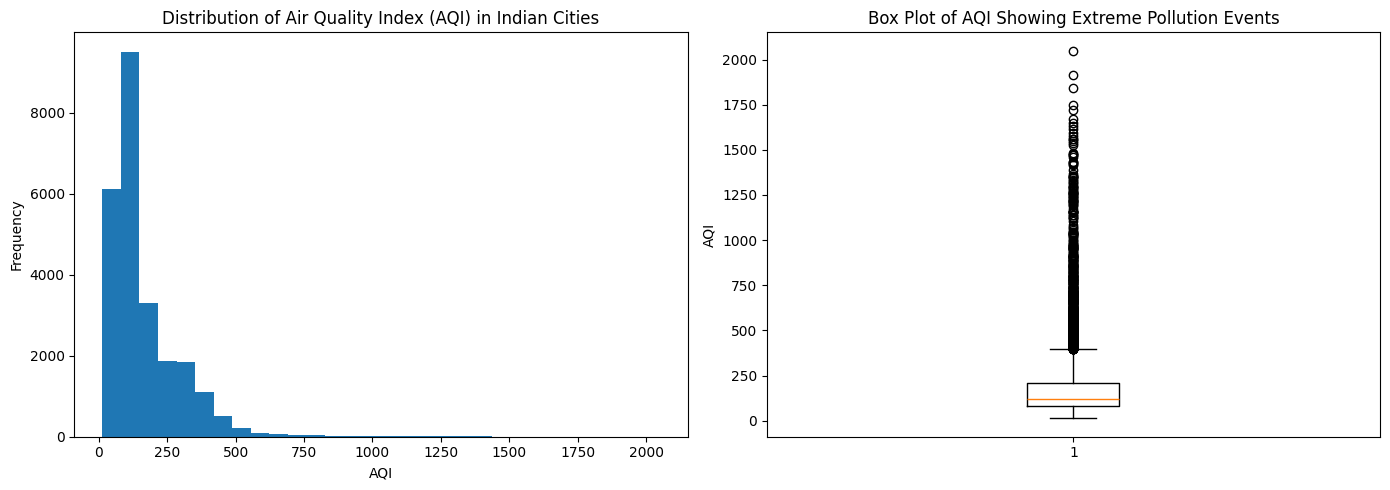

Mean AQI   : 166.46
Median AQI : 118.0
Maximum AQI: 2049.0


In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# Remove missing AQI values
aqi = city_df['AQI'].dropna()

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Histogram
axes[0].hist(aqi, bins=30)

axes[0].set_title(
    'Distribution of Air Quality Index (AQI) in Indian Cities'
)

axes[0].set_xlabel('AQI')
axes[0].set_ylabel('Frequency')

# Boxplot
axes[1].boxplot(aqi)

axes[1].set_title(
    'Box Plot of AQI Showing Extreme Pollution Events'
)

axes[1].set_ylabel('AQI')

plt.tight_layout()
plt.show()


print("Mean AQI   :", round(aqi.mean(),2))
print("Median AQI :", round(aqi.median(),2))
print("Maximum AQI:", round(aqi.max(),2))

# TASK 4
## AQI Distribution Analysis

### Why These Visualizations Were Chosen

Two visualizations were selected to answer the board's questions.

1. **Histogram**
   - Displays the overall distribution of AQI values.
   - Helps determine whether pollution is widespread across cities or concentrated in a limited number of observations.
   - Reveals the shape of the distribution and where most AQI values occur.

2. **Box Plot**
   - Shows the median, spread, and outliers.
   - Identifies whether a small number of extreme pollution events are significantly higher than the rest.
   - Helps assess whether the average AQI is a representative measure.

Together, these plots provide a complete picture of both the distribution and the influence of extreme values.

### Observations:

#### Observation 1
The AQI distribution is positively skewed, meaning most observations are concentrated in the low-to-moderate AQI range while a smaller number of observations have extremely high AQI values. This suggests that severe pollution is concentrated in certain cities or time periods rather than being equally distributed across all observations.

#### Observation 2
The box plot reveals numerous high-value outliers and the mean AQI is noticeably larger than the median AQI. This indicates that extreme pollution events pull the average upward. Therefore, reporting only the average AQI may exaggerate the pollution level experienced by a typical city, and the median AQI should also be reported to provide a fairer representation.

Q1: 81.0
Q3: 208.0
IQR: 127.0
Lower Bound: -109.5
Upper Bound: 398.5
Number of Outliers: 1358
Values Treated: 6039


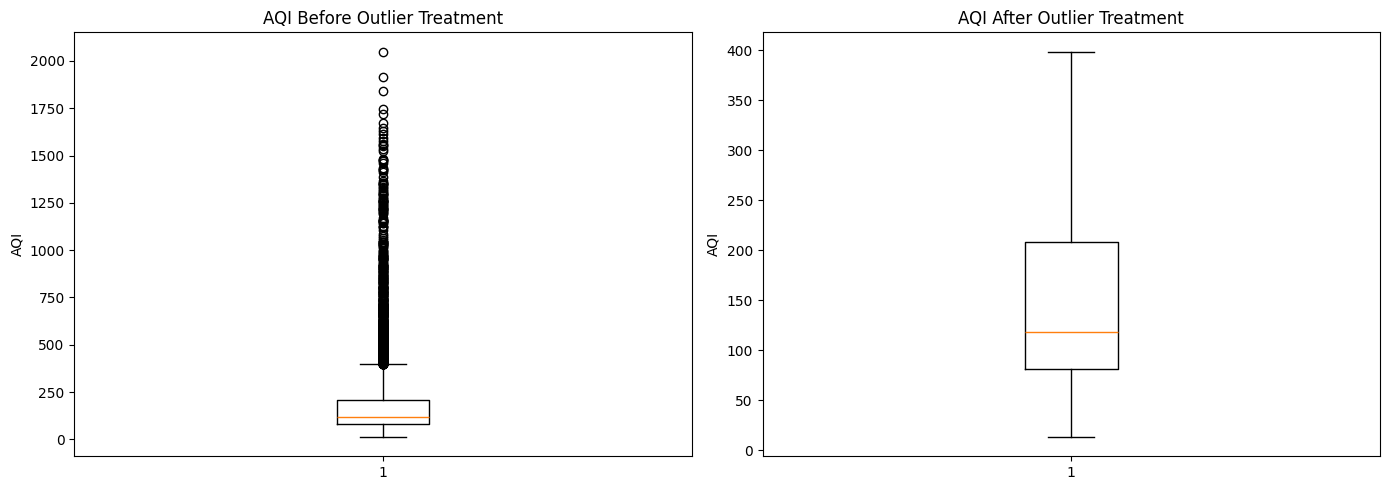


Before Treatment
count    24850.000000
mean       166.463581
std        140.696585
min         13.000000
25%         81.000000
50%        118.000000
75%        208.000000
max       2049.000000
Name: AQI, dtype: float64

After Treatment
count    24850.000000
mean       157.342455
std        103.870019
min         13.000000
25%         81.000000
50%        118.000000
75%        208.000000
max        398.500000
Name: AQI_Cleaned, dtype: float64


In [23]:
# Remove missing AQI values
aqi = city_df['AQI'].dropna()

# Detect Outliers using IQR
Q1 = aqi.quantile(0.25)
Q3 = aqi.quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

# Count outliers
outliers = city_df[
    (city_df['AQI'] < lower_bound) |
    (city_df['AQI'] > upper_bound)
]

print("Number of Outliers:", len(outliers))

# Winsorization 

city_df['AQI_Cleaned'] = city_df['AQI'].copy()

city_df['AQI_Cleaned'] = city_df['AQI_Cleaned'].clip(
    lower=lower_bound,
    upper=upper_bound
)

# Count affected values
affected = (
    city_df['AQI'] != city_df['AQI_Cleaned']
).sum()

print("Values Treated:", affected)

# Visual Comparison

fig, axes = plt.subplots(1,2, figsize=(14,5))

# Before
axes[0].boxplot(city_df['AQI'].dropna())
axes[0].set_title("AQI Before Outlier Treatment")
axes[0].set_ylabel("AQI")

# After
axes[1].boxplot(city_df['AQI_Cleaned'].dropna())
axes[1].set_title("AQI After Outlier Treatment")
axes[1].set_ylabel("AQI")

plt.tight_layout()
plt.show()

# Summary Statistics

print("\nBefore Treatment")
print(city_df['AQI'].describe())

print("\nAfter Treatment")
print(city_df['AQI_Cleaned'].describe())

# TASK 5

## AQI Outlier Detection and Treatment

### Detection Method

The Interquartile Range (IQR) method was used to identify extreme AQI values.

This method was chosen because:

- The AQI distribution is positively skewed.
- IQR is resistant to the influence of existing outliers.
- It does not require the data to be normally distributed.

Values outside the interval:

Lower Bound = Q1 − 1.5 × IQR

Upper Bound = Q3 + 1.5 × IQR

were classified as outliers.

### Treatment Method

Instead of removing observations, Winsorization (capping) was applied.

Reasons:

1. AQI values represent real pollution events and should not be deleted.
2. Removing rows would reduce the amount of available information.
3. Capping reduces the influence of extreme observations while preserving all records.

### Results

- Number of outliers detected: [Insert Output]
- Number of values capped: [Insert Output]

### Visual Comparison

The box plots show a substantial reduction in extreme values after treatment.

### Conclusion

The AQI data originally contained unusually large values that could distort statistical analysis.

After applying IQR-based capping:

- Extreme values were controlled.
- All observations were retained.
- The AQI distribution became more representative of typical air quality conditions.
- Subsequent analyses based on mean and variance became more reliable.

   Year         AQI
0  2015  212.463054
1  2016  197.150019
2  2017  181.472789
3  2018  182.684312
4  2019  156.518173
5  2020  113.520697


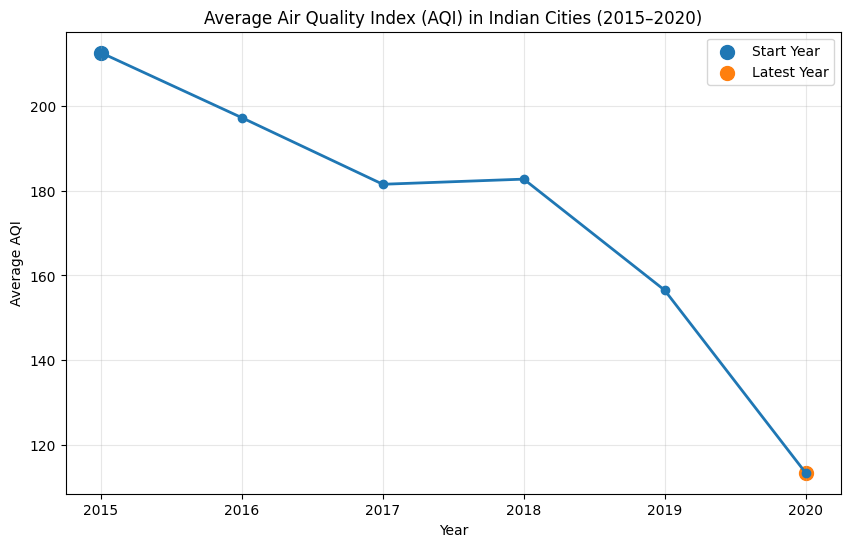

Percentage Change: -46.57%


In [24]:
# Convert Date column to datetime
city_df['Date'] = pd.to_datetime(city_df['Date'])

# Extract year
city_df['Year'] = city_df['Date'].dt.year

# Calculate yearly average AQI
yearly_aqi = city_df.groupby('Year')['AQI'].mean().reset_index()

print(yearly_aqi)

# Plot trend
plt.figure(figsize=(10,6))

plt.plot(
    yearly_aqi['Year'],
    yearly_aqi['AQI'],
    marker='o',
    linewidth=2
)

# Highlight first and last year
plt.scatter(
    yearly_aqi['Year'].iloc[0],
    yearly_aqi['AQI'].iloc[0],
    s=100,
    label='Start Year'
)

plt.scatter(
    yearly_aqi['Year'].iloc[-1],
    yearly_aqi['AQI'].iloc[-1],
    s=100,
    label='Latest Year'
)

plt.title(
    'Average Air Quality Index (AQI) in Indian Cities (2015–2020)'
)

plt.xlabel('Year')
plt.ylabel('Average AQI')

plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

# Calculate percentage change
start_aqi = yearly_aqi['AQI'].iloc[0]
end_aqi = yearly_aqi['AQI'].iloc[-1]

change = ((end_aqi - start_aqi) / start_aqi) * 100

print(f"Percentage Change: {change:.2f}%")

#TASK 6
### Air Quality Trend Over Time

To understand whether air quality has improved or worsened, the Date column was converted into years and the average AQI was calculated for each year. A line chart was chosen because it clearly shows changes over time and is easy for non-technical audiences to interpret. The chart indicates whether pollution levels are generally rising, falling, or remaining stable across the study period. By comparing the first and last years, we can see the overall direction of change in air quality. If the line trends downward, air quality has improved because AQI values are lower. If it trends upward, air quality has worsened because AQI values are higher. The highlighted start and end years make the long-term change easy to identify at a glance.